In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Packing Utilities

When building test chips or demo layouts you often need to arrange many cells
into a compact rectangular footprint without overlaps.  kfactory's
`kf.packing` module wraps the [rpack](https://github.com/Packer-Guy/rpack)
rectangle-packer to provide two convenience functions:

| Function | Input | Use case |
|---|---|---|
| `kf.packing.pack_kcells` | Sequence of `KCell` | Pack several cells into a new target cell |
| `kf.packing.pack_instances` | Sequence of `Instance` | Rearrange already-placed instances inside a cell |

Both functions return an `InstanceGroup` that lets you inspect or move the
placed instances as a unit.

## Setup

In [2]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Creating Diverse Components

We build a handful of rectangular cells with different sizes to illustrate
how the packer fits varied shapes together.

In [3]:
# (width_um, height_um) pairs — deliberately varied so the packing is non-trivial
sizes_um = [(5, 10), (20, 8), (3, 3), (15, 15), (8, 4), (12, 6), (6, 18), (9, 5)]

components = []
for w, h in sizes_um:
    c = kf.KCell(name=f"box_{w}x{h}")
    c.shapes(c.kcl.layer(L.WG)).insert(kf.kdb.Box(kf.kcl.to_dbu(w), kf.kcl.to_dbu(h)))
    components.append(c)

print(f"Created {len(components)} components")

Created 8 components


## 2 · `pack_kcells` — Basic Packing

`pack_kcells` instantiates each cell inside `target` and uses the
rectangle-packer to find a tight arrangement.

Key parameters:
- `max_width` / `max_height` — hard limits on the bounding box (dbu); `None` = unlimited
- `spacing` — extra gap between bounding boxes (dbu)

Bounding box: 45.0 µm × 22.0 µm
Placed 8 instances


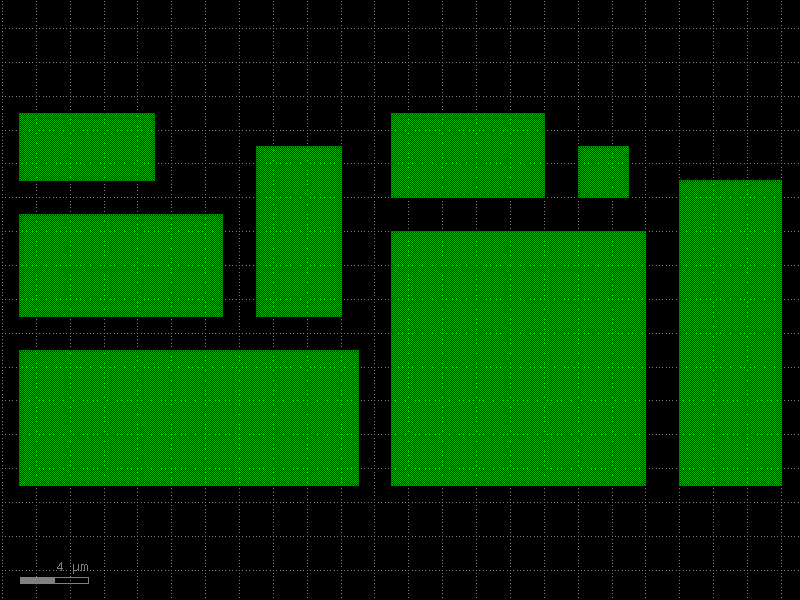

In [4]:
SPACING_DBU = kf.kcl.to_dbu(2)  # 2 µm gap between cells

target = kf.KCell(name="packed_basic")
ig = kf.packing.pack_kcells(target, components, spacing=SPACING_DBU)

print(
    f"Bounding box: {target.dbbox().width():.1f} µm × {target.dbbox().height():.1f} µm"
)
print(f"Placed {len(ig.insts)} instances")
target

The packer places all cells without overlap.  The bounding box is much smaller
than a naive row arrangement would produce.

## 3 · Width-Constrained Packing

Pass `max_width` (in dbu) to force the layout to stay within a given strip
width — useful for fitting onto a reticle column or a fixed-pitch test array.

Bounding box: 22.0 µm × 46.0 µm


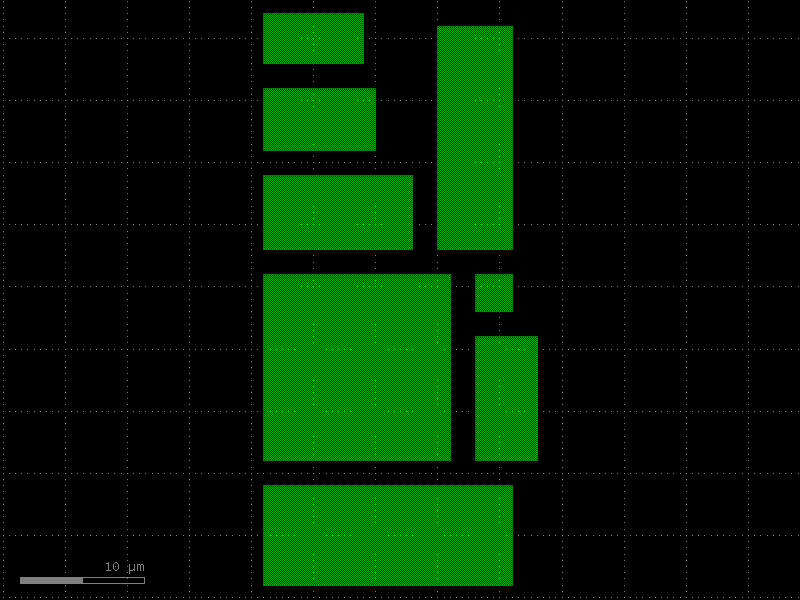

In [5]:
MAX_WIDTH_DBU = kf.kcl.to_dbu(25)  # 25 µm wide strip

target_narrow = kf.KCell(name="packed_narrow")
ig_narrow = kf.packing.pack_kcells(
    target_narrow,
    components,
    max_width=MAX_WIDTH_DBU,
    spacing=SPACING_DBU,
)

print(
    f"Bounding box: {target_narrow.dbbox().width():.1f} µm × "
    f"{target_narrow.dbbox().height():.1f} µm"
)
target_narrow

The layout is now taller and narrower compared to the unconstrained version.

## 4 · `pack_instances` — Rearranging Existing Instances

If instances are already present in a cell (e.g. placed by other routing
steps), `pack_instances` rearranges them in-place without creating new
instances.

Before packing — bbox: 217 µm × 218 µm
After  packing — bbox: 45 µm × 22 µm


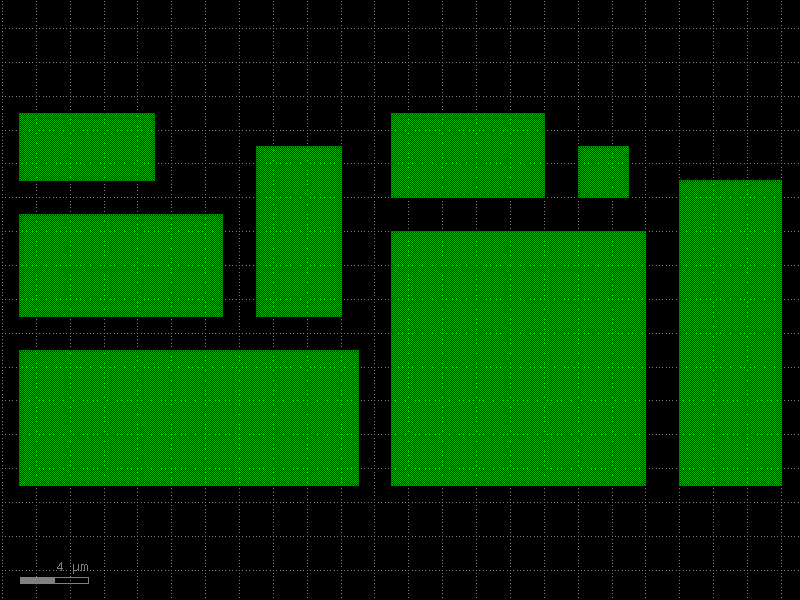

In [6]:
target_inst = kf.KCell(name="packed_instances")

# Pre-place instances at arbitrary positions
insts = [target_inst << c for c in components]
for i, inst in enumerate(insts):
    # Scatter them diagonally so the "before" layout is spread out
    inst.transform(kf.kdb.Trans(i * kf.kcl.to_dbu(30), i * kf.kcl.to_dbu(30)))

print(
    f"Before packing — bbox: {target_inst.dbbox().width():.0f} µm × {target_inst.dbbox().height():.0f} µm"
)

ig_inst = kf.packing.pack_instances(target_inst, insts, spacing=SPACING_DBU)

print(
    f"After  packing — bbox: {target_inst.dbbox().width():.0f} µm × {target_inst.dbbox().height():.0f} µm"
)
target_inst

## 5 · Using the Returned `InstanceGroup`

Both functions return an `InstanceGroup` so you can apply a common
transformation to the entire packed block — for example, to position it
relative to other structures in a larger layout.

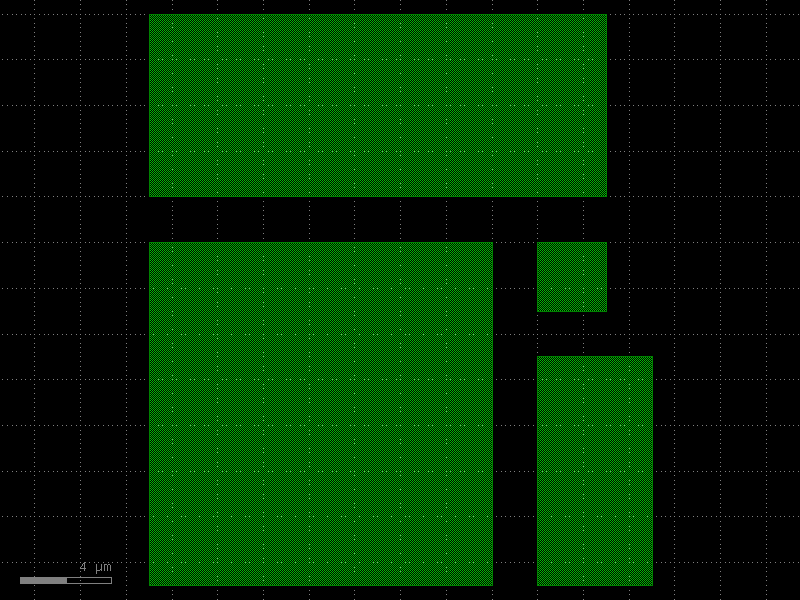

In [7]:
top = kf.KCell(name="top_chip")

# Pack a subset of components into a block
sub_target = kf.KCell(name="sub_block")
sub_ig = kf.packing.pack_kcells(sub_target, components[:4], spacing=SPACING_DBU)

# Place the packed block in the top-level cell and offset it
block_inst = top << sub_target
block_inst.transform(kf.kdb.Trans(kf.kcl.to_dbu(50), kf.kcl.to_dbu(20)))

top

## Quick Reference

```python
import kfactory as kf

# Pack a list of KCells into target (creates new instances)
ig = kf.packing.pack_kcells(
    target,
    cells,
    max_width=kf.kcl.to_dbu(100),   # optional width limit in dbu
    max_height=None,                  # optional height limit in dbu
    spacing=kf.kcl.to_dbu(2),        # gap between bboxes in dbu
)

# Rearrange already-placed instances (modifies their transforms)
ig = kf.packing.pack_instances(
    target,
    list_of_instances,
    spacing=kf.kcl.to_dbu(2),
)
```

## See Also

| Topic | Where |
|-------|-------|
| Array / grid layout | [Utilities: Grid](grid.py) |
| Components overview & gallery | [Components: Overview](../components/cells/overview.py) |
| Instance placement | [Core Concepts: Instances](../concepts/instances.py) |
| Creating a full PDK | [PDK: Creating a PDK](../pdk/creating_pdk.py) |